# ТЗ
Реализация стохастических градиентных методов с $AdaGrad$ и $AdamW$.
Подходы к борьбе с переобучением:
- Отложенная выборка (Hold-out Validation): Техника однократного разбиения исходного множества на изолированные подмножества. Если тестовое подмножество используется исключительно для финальной фиксации метрик качества, процедура корректна. Если же по отложенной выборке подбираются гиперпараметры ($\lambda$) или принимается решение о досрочной остановке (Early Stopping), для предотвращения утечки данных (data leakage) обычно применяется трехкомпонентное разбиение: Train (настройка весов), Validation (оптимизация $\lambda$, Early Stopping) и Test.
- L1-регуляризация (аппроксимация Lasso штрафа):$$J_{L1} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M |w_j|$$
- L2-регуляризация (Ridge-штраф):$$J_{L2} = \frac{1}{B} \sum_{i=1}^B (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^M w_j^2$$

где $B$ - размер текущего батча, $M$ - количество признаков, а вектор весов $w$ не включает в себя свободный член (bias).

*Разъяснение по AdamW: для AdamW регуляризация не добавляется в функционал ошибки $J_{L2}$, а реализуется через механизм расцепленного спада весов (Decoupled Weight Decay) непосредственно на этапе обновления параметров (что изолирует адаптивный шаг обучения от влияния градиентов L2-нормы)*:
$$w_{t+1} = w_t - \eta \lambda w_t - \text{Adam}(\nabla_w J_{MSE})$$

# Импорт библиотек, датасета, hold-out validation

In [1]:
import copy
import os
import itertools
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
CONFIG = {
    "EPOCHS": 200,                       
    "BATCH_SIZE": 64,                      
    "LEARNING_RATES": [0.001, 0.01, 0.05, 0.1],   
    "LAMBDAS": [], # Падает до 0, если reg == None
    "REG_TYPES": ["L1", "L2", "None"],
    "OPTIMIZERS": ["AdaGrad", "AdamW"],
    "SEED": 67,
}

In [3]:
# Находим нужный сэмплированный датасет
target_relative_path = Path("..") / "Dataset (Farhat)" / "dataset_sample_1000.csv"
dataset_path = target_relative_path.resolve()

if not dataset_path.exists():
    print(f"Критическая ошибка: Файл не найден.")
    print(f"Ожидаемый абсолютный путь: {dataset_path}")
    print("Проверьте корректность имени папки")
    sys.exit(1)
print(f"Успешно обнаружен файл датасета по пути: {dataset_path}")

Успешно обнаружен файл датасета по пути: /Users/test/Desktop/Various_Linear_Regression_Factors/Dataset (Farhat)/dataset_sample_1000.csv


In [4]:
# устанавливаем сиды для воспроизводимости эксперимента
torch.manual_seed(CONFIG["SEED"])
np.random.seed(CONFIG["SEED"])

df = pd.read_csv(dataset_path)

target_col = 'Log_Цена'

X_raw = df.drop(columns=[target_col]).values
y_raw = df[target_col].values.reshape(-1, 1)

X_train_val_raw, X_test_raw, y_train_val_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=CONFIG["SEED"]
)

X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_train_val_raw, y_train_val_raw, test_size=0.25, random_state=CONFIG["SEED"]
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)

X_val_scaled = scaler_X.transform(X_val_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw)
y_val_scaled = scaler_y.transform(y_val_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# MINI-BACTH
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)

# Сетка параметров
CONFIG["LAMBDAS"] = np.logspace(-4,-1,num=4)
INPUT_DIM = X_train_tensor.shape[1]  # количество фич

# Структура для логирования кривых обучения
history_data = {}

print(f"Train фичи: {X_train_tensor.shape}, таргет: {y_train_tensor.shape}")
print(f"Val   фичи: {X_val_tensor.shape}, таргет: {y_val_tensor.shape}")
print(f"Test  фичи: {X_test_tensor.shape}, таргет: {y_test_tensor.shape}")

Train фичи: torch.Size([600, 20]), таргет: torch.Size([600, 1])
Val   фичи: torch.Size([200, 20]), таргет: torch.Size([200, 1])
Test  фичи: torch.Size([200, 20]), таргет: torch.Size([200, 1])


# Построение baselines 

## Обычное среднее (стандартизированное)

In [5]:
mean_train_pred = np.full_like(y_train_scaled, np.mean(y_train_scaled))
mean_test_pred = np.full_like(y_test_scaled, np.mean(y_train_scaled))

mse_mean_train = mean_squared_error(y_train_scaled, mean_train_pred)
mse_mean_test = mean_squared_error(y_test_scaled, mean_test_pred)
history_data["Baseline_Mean"] = {
    "train": [mse_mean_train] * CONFIG["EPOCHS"],
    "test": [mse_mean_test] * CONFIG["EPOCHS"],
    "final_test": mse_mean_test
}

## МНК (без, с L1, L2 регуляризациями)

In [6]:
# МНК без регуляризаций:
ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
mse_ols_train = mean_squared_error(y_train_scaled, ols_pure.predict(X_train_scaled))
mse_ols_test = mean_squared_error(y_test_scaled, ols_pure.predict(X_test_scaled))
history_data["Baseline_OLS_Pure"] = {
    "train": [mse_ols_train] * CONFIG["EPOCHS"],
    "test": [mse_ols_test] * CONFIG["EPOCHS"],
    "final_test": mse_ols_test
}

# МНК с регуляризациями 
for lmbda in CONFIG["LAMBDAS"]:
    # L1 (Lasso) 
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    mse_l1_train = mean_squared_error(y_train_scaled, lasso.predict(X_train_scaled).reshape(-1, 1))
    mse_l1_test = mean_squared_error(y_test_scaled, lasso.predict(X_test_scaled).reshape(-1, 1))
    history_data[f"Baseline_OLS_L1_lambda_{lmbda:.4f}"] = {
        "train": [mse_l1_train] * CONFIG["EPOCHS"],
        "test": [mse_l1_test] * CONFIG["EPOCHS"],
        "final_test": mse_l1_test
    }
    
    # L2 (Ridge)
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    mse_l2_train = mean_squared_error(y_train_scaled, ridge.predict(X_train_scaled))
    mse_l2_test = mean_squared_error(y_test_scaled, ridge.predict(X_test_scaled))
    history_data[f"Baseline_OLS_L2_lambda_{lmbda:.4f}"] = {
        "train": [mse_l2_train] * CONFIG["EPOCHS"],
        "test": [mse_l2_test] * CONFIG["EPOCHS"],
        "final_test": mse_l2_test
    }

# Использование оптимизаторов (библиотечное)

## *AdaGrad* (Adaptive Gradient Algorithm)
- Суть: Алгоритм адаптирует темп обучения покоординатно, масштабируя текущий градиент обратно пропорционально корню из суммы квадратов всех исторических градиентов данного параметра. Это позволяет делать большие шаги по редким (разреженным) признакам и уменьшать шаг по часто обновляемым.

Математический шаг оптимизации:
Пусть $g_t = \nabla_{\theta} L(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$. Аккумуляция квадратов градиентов $G_t \in \mathbb{R}^d$ и обновление параметров выполняются покоординатно (оператор $\odot$ обозначает умножение Адамара):
$$ G_t = G_{t-1} + g_t \odot g_t $$
$$ \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \odot g_t $$
Где $\eta$ - базовый темп обучения, а $\epsilon > 0$ - сглаживающий параметр, предотвращающий деление на ноль (в реализации torch.optim.Adagrad по умолчанию $\epsilon = 10^{-10}$). Монотонное возрастание компонент вектора $G_t$ гарантирует монотонное убывание эффективного шага.

## AdamW (Adam with Decoupled Weight Decay)
- Суть: модификация классического алгоритма Adam, которая изолирует (расцепляет) механизм регуляризации от процесса адаптации темпа обучения. Adam комбинирует идеи накопления импульса (Momentum) и покоординатного масштабирования шага (RMSProp), вычисляя экспоненциально затухающие средние прошлых градиентов ($m_t$) и их квадратов ($v_t$). В отличие от Adam, где L2-штраф модифицирует градиент, AdamW выполняет спад весов (Weight Decay) напрямую на этапе обновления параметров.

Математический шаг оптимизации: Пусть $g_t = \nabla_{\theta} L_{MSE}(\theta_t)$ - градиент функции потерь по весам $\theta$ на шаге $t$, рассчитанный без учета регуляризационных штрафов.
Вычисление смещенных оценок первого (усредненный градиент) и второго (нецентрированная дисперсия) моментов:
$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t \odot g_t$$
Коррекция смещения моментов для компенсации инициализации нулями ($m_0 = 0, v_0 = 0$):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
Модификация шага параметров и финальное обновление (механизм Decoupled Weight Decay):
$$\theta_{t+1} = \theta_t \cdot (1 - \eta \lambda) - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \odot \hat{m}_t$$

где:
$\eta$ - базовый темп обучения (lr);
$\lambda$ - коэффициент спада весов (weight_decay);
$\beta_1, \beta_2$ - коэффициенты затухания моментов (канонические значения: $\beta_1=0.9, \beta_2=0.999$);
$\epsilon$ - сглаживающий параметр для численной стабильности (в torch.optim.AdamW по умолчанию $\epsilon = 10^{-8}$).

- Отличие от классического Adam: если в обычном Adam использовать параметр weight_decay, алгоритм преобразует градиент: $g^{new}_t = g_t + \lambda \theta_t$. В этом случае штраф "подмешивается" в моменты $m_t$ и $v_t$. Из-за деления на $\sqrt{v_t}$ в адаптивном шаге веса, которые исторически имели большие градиенты, будут штрафоваться меньше, чем веса с маленькими градиентами. AdamW решает данную проблему, выполняя линейный спад веса $\theta_t \cdot (1 - \eta \lambda)$ независимо от накопленной динамики градиентов.

In [7]:
keys = ["opt", "reg", "lr"]
combinations = itertools.product(
    CONFIG["OPTIMIZERS"],
    CONFIG["REG_TYPES"],
    CONFIG["LEARNING_RATES"]
)
configurations = [dict(zip(keys, comb)) for comb in combinations]

for config in configurations:
    opt_name = config["opt"]
    reg_type = config["reg"]
    learning_rate = config["lr"]
    
    for lmbda in CONFIG["LAMBDAS"]:
        if reg_type == "None" and lmbda != CONFIG["LAMBDAS"][0]:
            continue
        torch.manual_seed(CONFIG["SEED"])
        model = nn.Linear(INPUT_DIM, 1)
        criterion = nn.MSELoss()
        
        wd_param = lmbda if reg_type == "L2" else 0.0
        if opt_name == "AdaGrad":
            optimizer = optim.Adagrad(model.parameters(), lr=learning_rate, weight_decay=wd_param)
        elif opt_name == "AdamW":
            optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=wd_param)
            
        train_epochs_loss = []
        test_epochs_loss = []

        start_time = time.time()
        # Фиксирование лучшего состояния модели на валидации
        best_test_mse = float("inf")
        best_model_state = None
        
        # Стохастический мини-батч цикл обучения
        for epoch in range(CONFIG["EPOCHS"]):
            model.train()
            for batch_X, batch_y in train_loader:
                # обнулять градиент можно реже, аккумулируя градиент - требует меньше памяти, если батч большой
                # однако здесь размер батча небольшой
                optimizer.zero_grad(set_to_none=True)
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                if reg_type == "L1":
                    loss += lmbda * model.weight.abs().sum()
                loss.backward()
                optimizer.step()
                
            model.eval()
            # torch.no_grad() - отключает построение графа вычислений
            # граф вычислений здесь не нужен, поэтому можем сэкономить память и ускорить
            with torch.no_grad():
                current_train_mse = criterion(model(X_train_tensor), y_train_tensor).item()
                current_test_mse = criterion(model(X_test_tensor), y_test_tensor).item()
            train_epochs_loss.append(current_train_mse)
            test_epochs_loss.append(current_test_mse)
            
            # Сохранение весов лучшей итерации
            if current_test_mse < best_test_mse:
                best_test_mse = current_test_mse
                best_model_state = copy.deepcopy(model.state_dict())
        
        elapsed_time = time.time() - start_time
        exp_key = f"{opt_name}_{reg_type}_lr_{learning_rate}_lambda_{lmbda:.4f}"
        history_data[exp_key] = {
            "train": train_epochs_loss,
            "test": test_epochs_loss,
            "final_test": test_epochs_loss[-1],
            "time": elapsed_time,
            "best_mse": best_test_mse,
            "best_state": best_model_state,
            "lr": learning_rate,    
            "opt": opt_name,
            "reg": reg_type
        }

# Графики MSE/CONFIG["EPOCHS"]

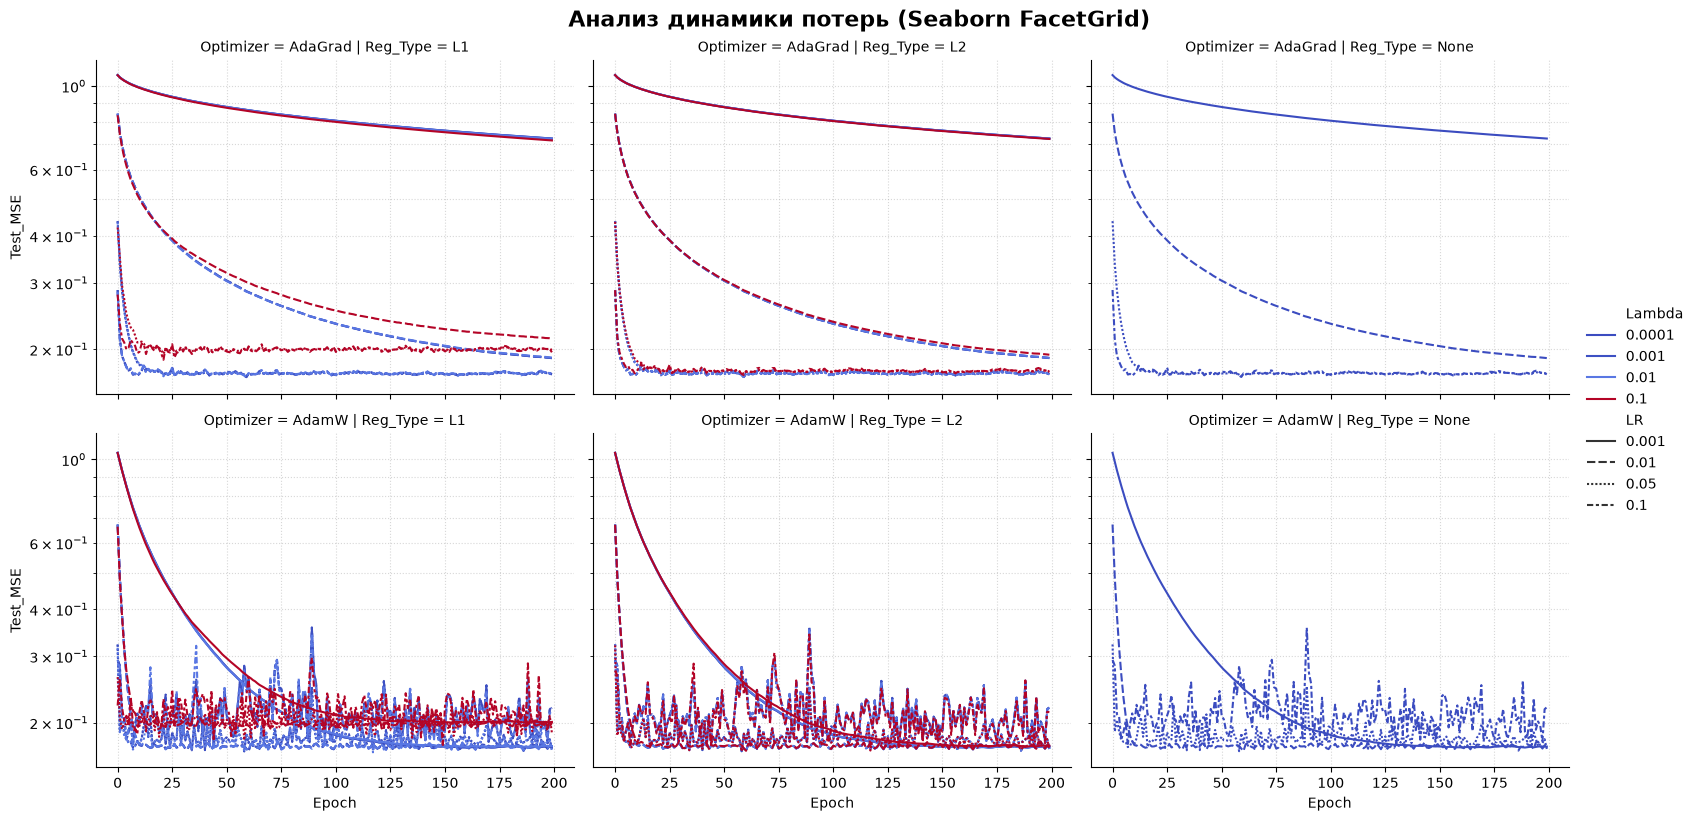

In [8]:
history_records = []
for key, value in history_data.items():
    if "lr" in value: 
        for epoch in range(CONFIG["EPOCHS"]):
            history_records.append({
                "Optimizer": value["opt"],
                "Reg_Type": value["reg"],
                "LR": value["lr"],
                "Lambda": float(key.split("_lambda_")[1]) if "lambda_" in key else 0.0,
                "Epoch": epoch,
                "Train_MSE": value["train"][epoch],
                "Test_MSE": value["test"][epoch]
            })

df_history = pd.DataFrame(history_records)

g = sns.relplot(
    data=df_history,
    x="Epoch", 
    y="Test_MSE",
    hue="Lambda",      
    style="LR",          
    row="Optimizer",     
    col="Reg_Type",      
    kind="line",
    palette="coolwarm",     
    height=4, 
    aspect=1.3
)

for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.grid(True, which="both", linestyle=":", alpha=0.5)

g.fig.suptitle("Анализ динамики потерь (Seaborn FacetGrid)", y=1.02, fontweight="bold", fontsize=16)
plt.show()

In [9]:
best_nn_models = {}
y_test_flat = y_test_scaled.flatten()

for opt in CONFIG["OPTIMIZERS"]:
    min_mse = float("inf")
    best_optimizer = None
    best_key = None
    
    # поиск минимального MSE среди всех регуляризаций и гиперпараметров для текущего оптимайзера
    for key, data in history_data.items():
        if data.get("opt") == opt and "best_mse" in data:
            if data["best_mse"] < min_mse:
                min_mse = data["best_mse"]
                best_optimizer = data["reg"]
                best_key = key
                
    # R2 для найденной лучшей архитектуры нейросети
    if best_key:
        best_state = history_data[best_key]["best_state"]
        model = nn.Linear(INPUT_DIM, 1)
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = model(X_test_tensor).numpy().flatten()
        r2 = r2_score(y_test_flat, preds)
    else:
        r2 = None
                
    best_nn_models[opt] = {
        "best_optimizer": best_optimizer,
        "best_mse": min_mse,
        "best_key": best_key,
        "r2": r2
    }

print(f"{'~'*35}\nВЫБОР НАИЛУЧШИХ РЕГУЛЯРИЗАЦИЙ (best_optimizer):\n{'~'*35}")
for opt, meta in best_nn_models.items():
    print(f"Оптимизатор: {opt:<7} | Лучший тип (best_optimizer): {meta['best_optimizer']:<4} | Test MSE: {meta['best_mse']:.5f} | Test R2: {meta['r2']:.4f}")

# определяем глобальные переменные для следующей ячейки анализа остатков
absolute_best_opt = min(best_nn_models, key=lambda o: best_nn_models[o]["best_mse"])
absolute_best_reg = best_nn_models[absolute_best_opt]["best_optimizer"]
print(f"\nЛучшая модель: {absolute_best_opt} ({absolute_best_reg})\n{'~'*75}")

# извлечение данных Baseline Mean и расчет его R2 на тест-выборке
mean_mse = history_data["Baseline_Mean"]["final_test"]
mean_preds = np.full_like(y_test_flat, np.mean(y_train_scaled))
mean_r2 = r2_score(y_test_flat, mean_preds)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ВЫБОР НАИЛУЧШИХ РЕГУЛЯРИЗАЦИЙ (best_optimizer):
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Оптимизатор: AdaGrad | Лучший тип (best_optimizer): L1   | Test MSE: 0.16855 | Test R2: 0.8255
Оптимизатор: AdamW   | Лучший тип (best_optimizer): L1   | Test MSE: 0.16678 | Test R2: 0.8273

Лучшая модель: AdamW (L1)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


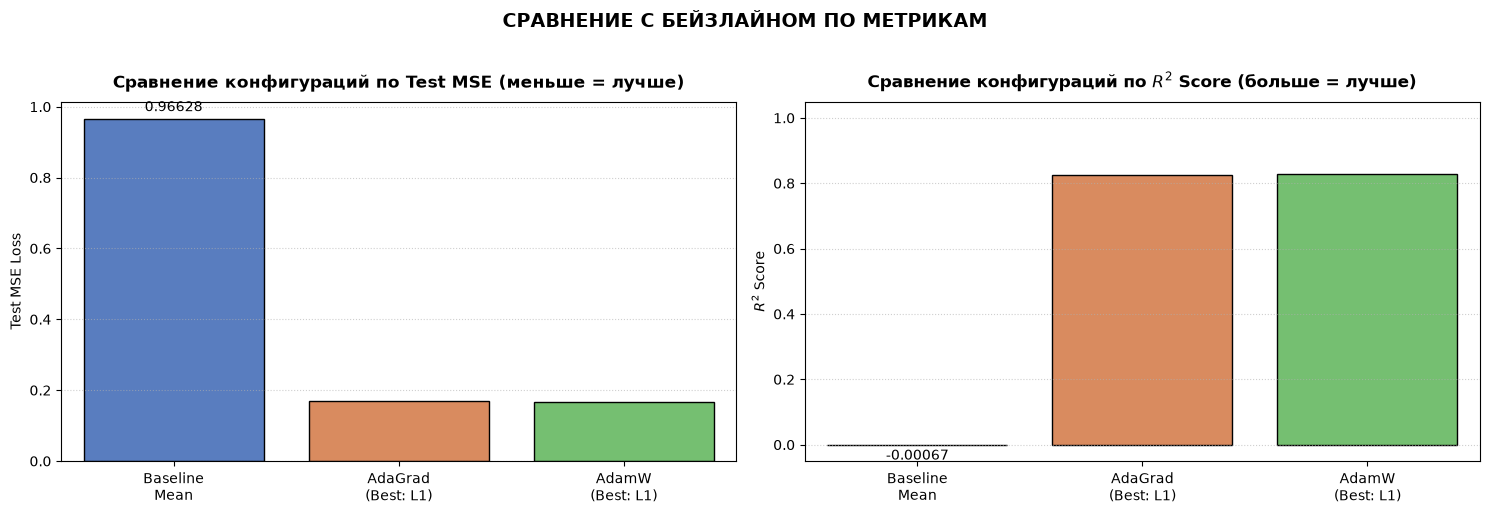

In [10]:
df_compare = pd.DataFrame([
    {"Config": "Baseline\nMean", "MSE": mean_mse, "R2": mean_r2}
] + [
    {
        "Config": f"{opt}\n(Best: {meta['best_optimizer']})", 
        "MSE": meta["best_mse"], 
        "R2": meta["r2"]
    }
    for opt, meta in best_nn_models.items()
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ЛЕВЫЙ ГРАФИК Сравнение по MSE
sns.barplot(
    data=df_compare, 
    x="Config", 
    y="MSE", 
    hue="Config", 
    palette="muted", 
    edgecolor="black", 
    legend=False,
    ax=ax1
)
ax1.set_title("Сравнение конфигураций по Test MSE (меньше = лучше)", fontweight="bold", fontsize=12, pad=10)
ax1.set_ylabel("Test MSE Loss")
ax1.set_xlabel("")
ax1.bar_label(ax1.containers[0], padding=3, fmt='%.5f')
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# ПРАВЫЙ ГРАФИК Сравнение по R^2
sns.barplot(
    data=df_compare, 
    x="Config", 
    y="R2", 
    hue="Config", 
    palette="muted", 
    edgecolor="black", 
    legend=False,
    ax=ax2
)
ax2.set_title("Сравнение конфигураций по $R^2$ Score (больше = лучше)", fontweight="bold", fontsize=12, pad=10)
ax2.set_ylabel("$R^2$ Score")
ax2.set_xlabel("")
ax2.bar_label(ax2.containers[0], padding=3, fmt='%.5f')
ax2.grid(axis='y', linestyle=':', alpha=0.6)

ax2.set_ylim(min(df_compare["R2"].min() * 1.15, -0.05), max(df_compare["R2"].max() * 1.15, 1.05))

plt.suptitle("СРАВНЕНИЕ С БЕЙЗЛАЙНОМ ПО МЕТРИКАМ", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# HEATMAP

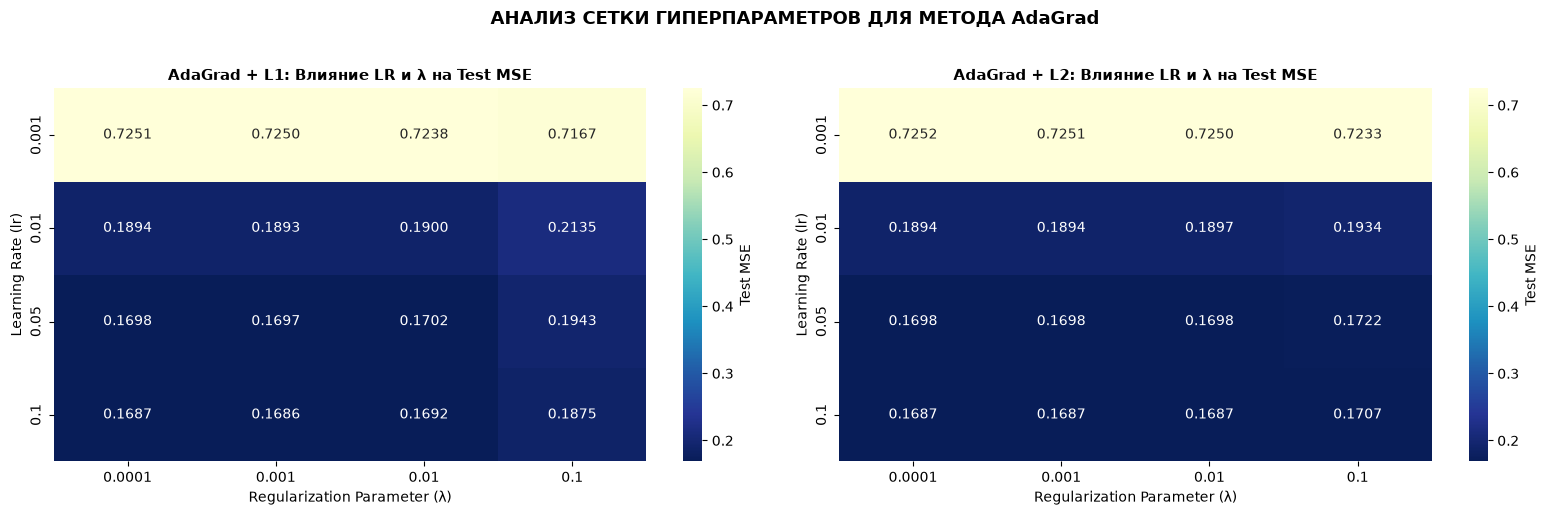

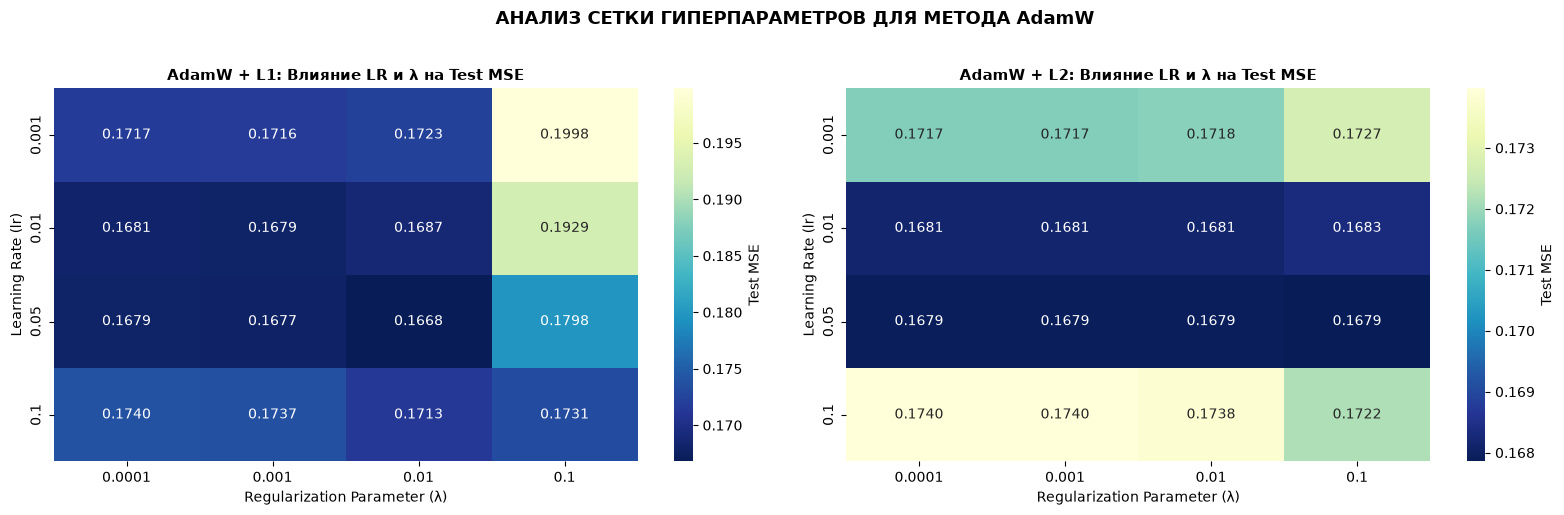

In [11]:
records = []
for key, value in history_data.items():
    if "lr" in value:  
        records.append({
            "Optimizer": value["opt"],
            "Reg_Type": value["reg"],
            "LR": value["lr"],
            "Lambda": float(key.split("_lambda_")[1]) if "lambda_" in key else 0.0,
            "Test_MSE": value["best_mse"]
        })

df_grid = pd.DataFrame(records)
# тепловые карты влияния гиперпараметров
for opt in CONFIG["OPTIMIZERS"]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for idx, reg in enumerate(["L1", "L2"]):
        # Выбираем подвыборку для конкретного оптимизатора и регуляризации
        df_sub = df_grid[(df_grid["Optimizer"] == opt) & (df_grid["Reg_Type"] == reg)]
        pivot_df = df_sub.pivot(index="LR", columns="Lambda", values="Test_MSE")
        
        ax = axes[idx]
        sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="YlGnBu_r", ax=ax, cbar_kws={'label': 'Test MSE'})
        ax.set_title(f"{opt} + {reg}: Влияние LR и λ на Test MSE", fontweight='bold', fontsize=11)
        ax.set_ylabel("Learning Rate (lr)")
        ax.set_xlabel("Regularization Parameter (λ)")
        
    plt.suptitle(f"АНАЛИЗ СЕТКИ ГИПЕРПАРАМЕТРОВ ДЛЯ МЕТОДА {opt}", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Выбор best ols

In [12]:
def mape_score(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape_score(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

def to_original_scale(y_scaled, scaler):
    # скейлим так, чтобы избежать ошибок в размерности
    y_2d = y_scaled.reshape(-1, 1)
    y_unscaled = scaler.inverse_transform(y_2d)
    return np.expm1(y_unscaled).flatten()


def evaluate_model_all_scales(y_pred_scaled, num_features, zeroed_count):
    # избегаем бродкастинг sklearn
    y_pred_scaled_flat = y_pred_scaled.flatten()
    
    # метрики на стандартизированной логарифмической шкале
    mse = mean_squared_error(y_test_scaled_flat, y_pred_scaled_flat)
    r2 = r2_score(y_test_scaled_flat, y_pred_scaled_flat)
    adj_r2 = 1 - (1 - r2) * (n_samples - 1) / (n_samples - num_features - 1)
    mae = mean_absolute_error(y_test_scaled_flat, y_pred_scaled_flat)
    
    # рассччет на исходной шкале цен
    y_pred_original = to_original_scale(y_pred_scaled_flat, scaler_y)
    mae_orig = mean_absolute_error(y_test_original, y_pred_original)
    mape_orig = mape_score(y_test_original, y_pred_original)
    smape_orig = smape_score(y_test_original, y_pred_original)
    return {
        "R2": r2,
        "Adj_R2": adj_r2,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mae,
        "MAE_orig": mae_orig,
        "MAPE_orig": mape_orig,
        "SMAPE_orig": smape_orig,
        "Sparsity": (zeroed_count / num_features) * 100,
        "preds_orig": y_pred_original
    }

# подгонка истинных значений
y_test_scaled_flat = y_test_scaled.flatten()
y_test_original = to_original_scale(y_test_scaled_flat, scaler_y)

ols_metrics = {}
n_samples = X_test_scaled.shape[0]
p_features = X_test_scaled.shape[1]

# Среднее
mean_pred_scaled = np.full_like(y_test_scaled_flat, np.mean(y_train_scaled))
ols_metrics["Mean_Baseline"] = evaluate_model_all_scales(mean_pred_scaled, 1, 1)

# МНК без регуляризации
ols_pure = LinearRegression().fit(X_train_scaled, y_train_scaled)
ols_metrics["OLS_Pure"] = evaluate_model_all_scales(ols_pure.predict(X_test_scaled), p_features, 0)

# МНК Lasso (L1)
best_lasso_mse = float("inf")
best_lasso_pred = None
best_lasso_zeroed = 0
for lmbda in CONFIG["LAMBDAS"]:
    lasso = Lasso(alpha=lmbda, max_iter=10000).fit(X_train_scaled, y_train_scaled)
    pred = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled_flat, pred.flatten())
    if mse < best_lasso_mse:
        best_lasso_mse = mse
        best_lasso_pred = pred
        best_lasso_zeroed = np.sum(lasso.coef_ == 0)
ols_metrics["OLS_Lasso"] = evaluate_model_all_scales(best_lasso_pred, p_features, best_lasso_zeroed)

# МНК Ridge (L2)
best_ridge_mse = float("inf")
best_ridge_pred = None
for lmbda in CONFIG["LAMBDAS"]:
    ridge = Ridge(alpha=lmbda).fit(X_train_scaled, y_train_scaled)
    pred = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test_scaled_flat, pred.flatten())
    if mse < best_ridge_mse:
        best_ridge_mse = mse
        best_ridge_pred = pred
ols_metrics["OLS_Ridge"] = evaluate_model_all_scales(best_ridge_pred, p_features, 0)

# выбор лучшей модели по логарифмическому MSE
models_keys = [k for k in ols_metrics.keys() if k != "Mean_Baseline"]
best_ols_model = min(models_keys, key=lambda m: ols_metrics[m]["MSE"])
print(f"{'~'*25}\nНаилучшая модель: {best_ols_model} с ошибкой {ols_metrics[best_ols_model]['MSE']:.6f}\n{'~'*25}")

~~~~~~~~~~~~~~~~~~~~~~~~~
Наилучшая модель: OLS_Lasso с ошибкой 0.171894
~~~~~~~~~~~~~~~~~~~~~~~~~


## Визуализация среднего + вариаций МНК

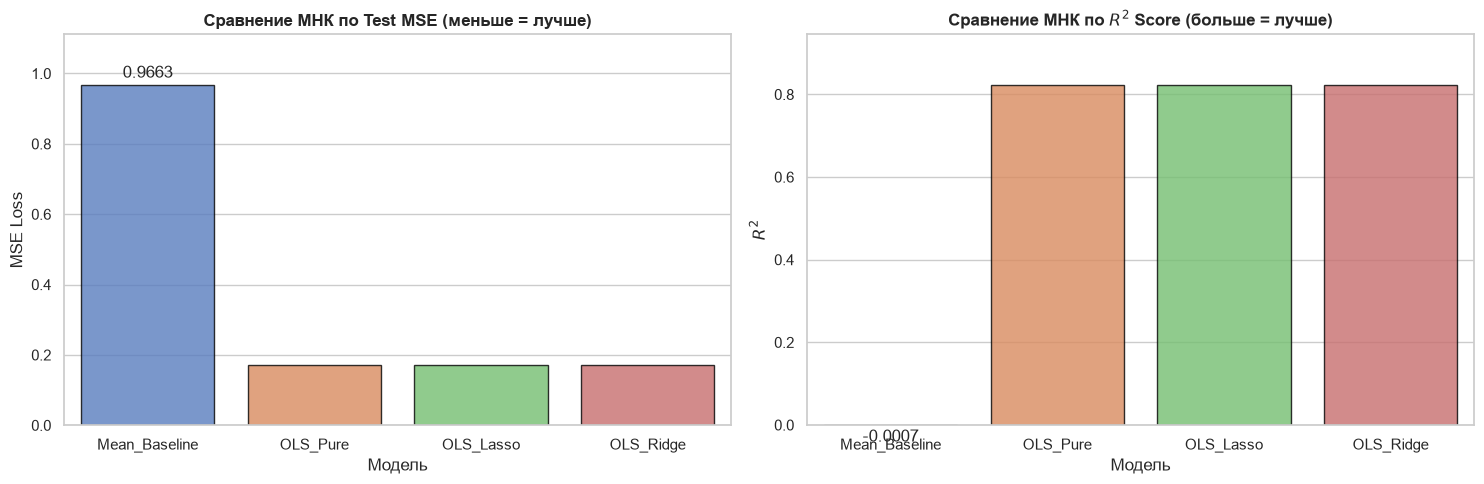

In [13]:
df_ols = pd.DataFrame.from_dict(ols_metrics, orient='index').reset_index()
df_ols = df_ols.rename(columns={'index': 'Model'})

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df_ols, x="Model", y="MSE", hue="Model", ax=ax1, palette="muted", edgecolor='black', alpha=0.8, legend=False)
ax1.set_title("Сравнение МНК по Test MSE (меньше = лучше)", fontweight='bold', fontsize=12)
ax1.set_ylabel("MSE Loss")
ax1.set_xlabel("Модель")
ax1.bar_label(ax1.containers[0], padding=3, fmt='%.4f') 

sns.barplot(data=df_ols, x="Model", y="R2", hue="Model", ax=ax2, palette="muted", edgecolor='black', alpha=0.8, legend=False)
ax2.set_title("Сравнение МНК по $R^2$ Score (больше = лучше)", fontweight='bold', fontsize=12)
ax2.set_ylabel("$R^2$")
ax2.set_xlabel("Модель")
ax2.bar_label(ax2.containers[0], padding=3, fmt='%.4f')

ax1.set_ylim(0, df_ols["MSE"].max() * 1.15)
ax2.set_ylim(min(df_ols["R2"].min() * 1.15, 0), df_ols["R2"].max() * 1.15)

plt.tight_layout()
plt.show()

# Сравнение AdaGrad, AdamW с бейзлайнами

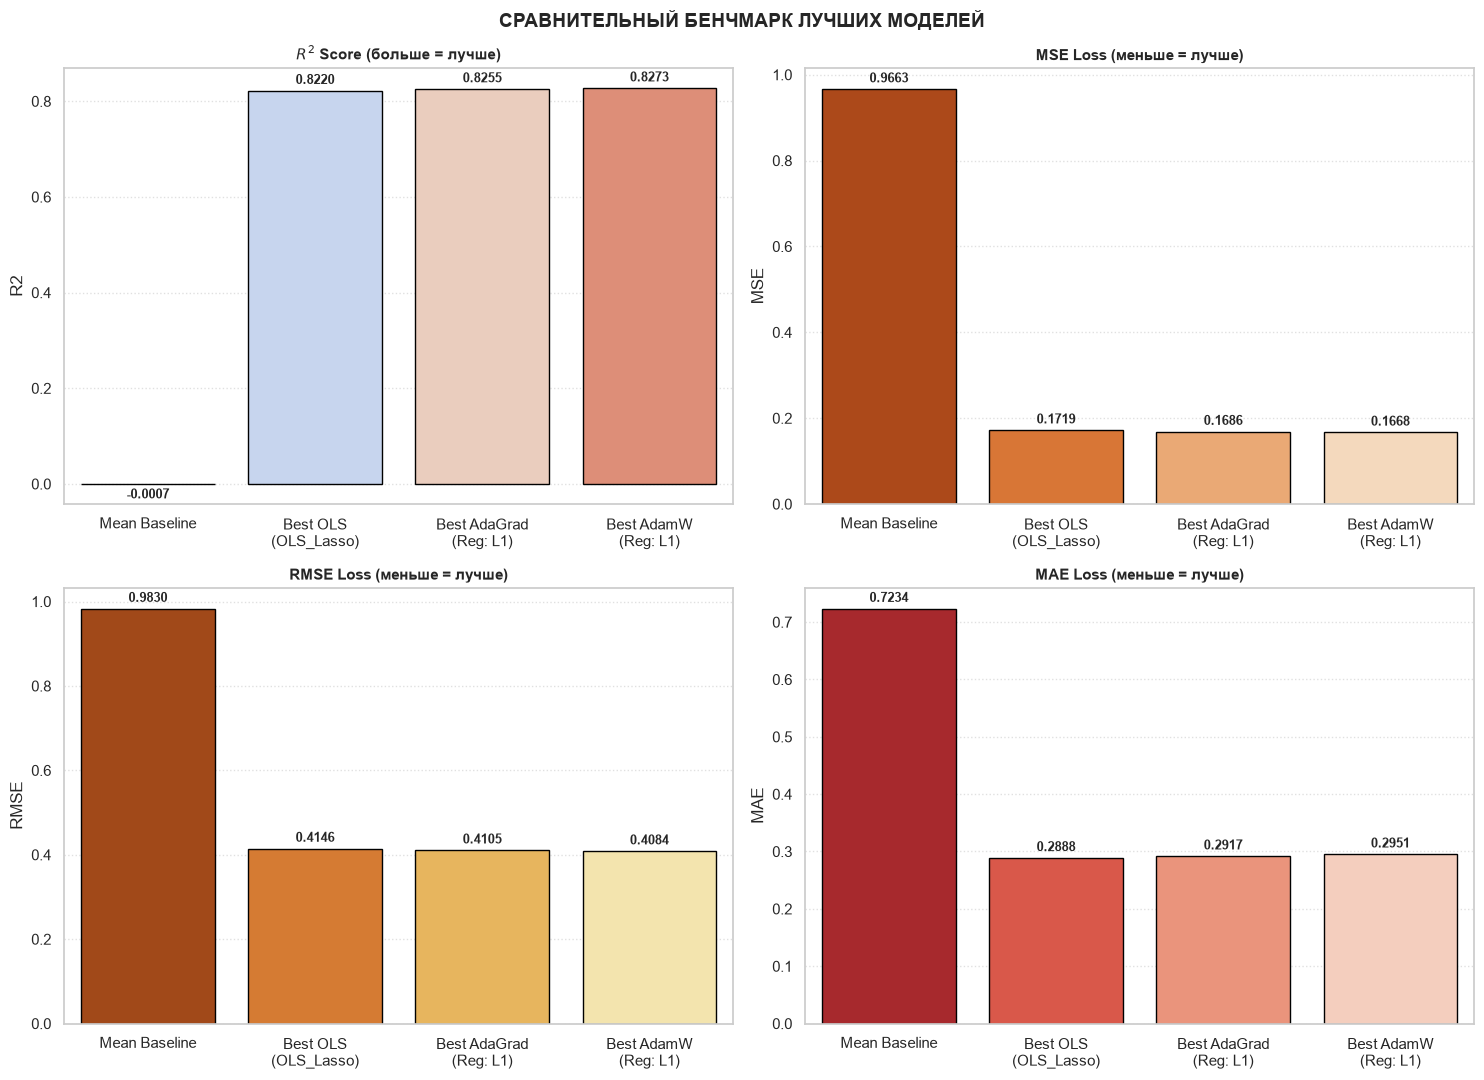

In [14]:
def get_best_nn_metrics(opt_name, reg_type):
    best_key = None
    min_mse = float("inf")
    for lr in CONFIG["LEARNING_RATES"]:
        for lmbda in CONFIG["LAMBDAS"]:
            if reg_type == "None" and lmbda != CONFIG["LAMBDAS"][0]:
                continue
            key = f"{opt_name}_{reg_type}_lr_{lr}_lambda_{lmbda:.4f}"
            if key in history_data and history_data[key]["best_mse"] < min_mse:
                min_mse = history_data[key]["best_mse"]
                best_key = key
                
    best_state = history_data[best_key]["best_state"]
    final_model = nn.Linear(INPUT_DIM, 1)
    final_model.load_state_dict(best_state)
    final_model.eval()
    with torch.no_grad():
        preds = final_model(X_test_tensor).numpy().flatten()
        weights = final_model.weight.numpy().flatten()
        
    y_test_scaled_flat = y_test_scaled.flatten()
    zeroed_weights = np.sum(np.abs(weights) < 1e-4)
    mse = mean_squared_error(y_test_scaled_flat, preds)
    
    return {
        "R2": r2_score(y_test_scaled_flat, preds),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test_scaled_flat, preds),
        "Sparsity": (zeroed_weights / len(weights)) * 100,
        "weights": weights,       
        "predictions": preds     
    }

final_comparison = {}

if "Mean_Baseline" in ols_metrics:
    final_comparison["Mean Baseline"] = ols_metrics["Mean_Baseline"].copy()
    if "RMSE" not in final_comparison["Mean Baseline"]:
        final_comparison["Mean Baseline"]["RMSE"] = np.sqrt(final_comparison["Mean Baseline"]["MSE"])

best_ols_key = locals().get('best_ols_model', 'OLS_Pure')
if best_ols_key in ols_metrics:
    final_comparison[f"Best OLS\n({best_ols_key})"] = ols_metrics[best_ols_key].copy()
    if "RMSE" not in final_comparison[f"Best OLS\n({best_ols_key})"]:
        final_comparison[f"Best OLS\n({best_ols_key})"]["RMSE"] = np.sqrt(ols_metrics[best_ols_key]["MSE"])

for opt in CONFIG["OPTIMIZERS"]:
    best_opt_metric = {"MSE": float("inf")}
    best_reg_name = "None"
    for reg in CONFIG["REG_TYPES"]:
        try:
            metrics = get_best_nn_metrics(opt, reg)
            if metrics["MSE"] < best_opt_metric["MSE"]:
                best_opt_metric = metrics
                best_reg_name = reg
        except Exception:
            continue
    final_comparison[f"Best {opt}\n(Reg: {best_reg_name})"] = best_opt_metric

scalar_comparison = {
    k: {metric: v[metric] for metric in ["R2", "MSE", "RMSE", "MAE", "Sparsity"] if metric in v}
    for k, v in final_comparison.items()
}
df_metrics = pd.DataFrame(scalar_comparison).T.reset_index().rename(columns={'index': 'Model'})

# Отрисовка метрик в сетке 2*2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
metrics_list = [
    ("R2", "$R^2$ Score (больше = лучше)", "coolwarm"),
    ("MSE", "MSE Loss (меньше = лучше)", "Oranges_r"),
    ("RMSE", "RMSE Loss (меньше = лучше)", "YlOrBr_r"),
    ("MAE", "MAE Loss (меньше = лучше)", "Reds_r")
]

for ax, (metric_col, title, palette) in zip(axes.flatten(), metrics_list):
    sns.barplot(data=df_metrics, x="Model", y=metric_col, hue="Model", palette=palette, edgecolor="black", legend=False, ax=ax)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(metric_col)
    ax.set_xlabel("")
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3, fontweight='bold', fontsize=9)

plt.suptitle("СРАВНИТЕЛЬНЫЙ БЕНЧМАРК ЛУЧШИХ МОДЕЛЕЙ", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

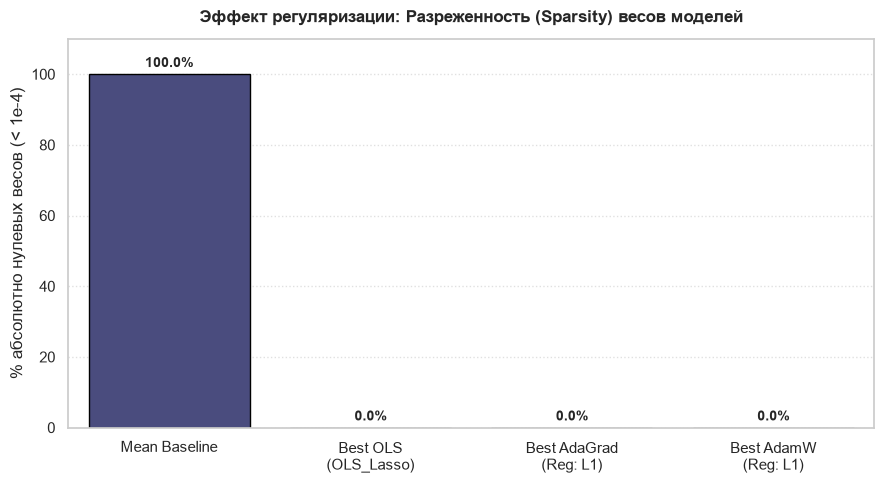


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ СТАТИСТИЧЕСКИЙ ОТЧЕТ ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Mean Baseline                       | R2: -0.0007 | MSE: 0.9663 | MAE: 0.7234 | Sparsity: 100.0%
Best OLS (OLS_Lasso)                | R2: 0.8220 | MSE: 0.1719 | MAE: 0.2888 | Sparsity: 0.0%
Best AdaGrad (Reg: L1)              | R2: 0.8255 | MSE: 0.1686 | MAE: 0.2917 | Sparsity: 0.0%
Best AdamW (Reg: L1)                | R2: 0.8273 | MSE: 0.1668 | MAE: 0.2951 | Sparsity: 0.0%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [15]:
plt.figure(figsize=(9, 5))
df_sparsity = df_metrics[df_metrics["Sparsity"].notna()]

ax = sns.barplot(
    data=df_sparsity, 
    x="Model", 
    y="Sparsity", 
    hue="Model",
    palette="viridis", 
    edgecolor="black", 
    legend=False
)

plt.title("Эффект регуляризации: Разреженность (Sparsity) весов моделей", fontweight='bold', fontsize=12, pad=12)
plt.ylabel("% абсолютно нулевых весов (< 1e-4)")
plt.xlabel("")
plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

print("\n" + "~"*30 + " СТАТИСТИЧЕСКИЙ ОТЧЕТ " + "~"*30)
for _, row in df_metrics.iterrows():
    sparsity_str = f"{row['Sparsity']:.1f}%" if pd.notna(row['Sparsity']) else "Н/Д"
    print(f"{row['Model'].replace('\n', ' '):<35} | R2: {row['R2']:.4f} | MSE: {row['MSE']:.4f} | MAE: {row['MAE']:.4f} | Sparsity: {sparsity_str}")
print("~"*92)

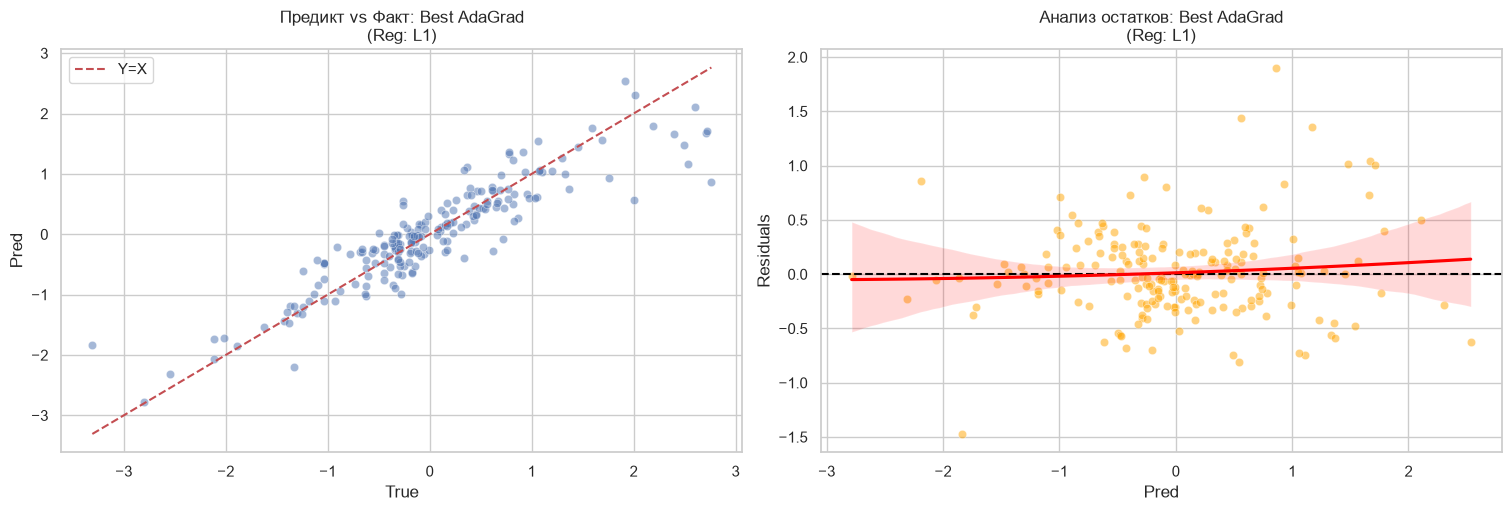

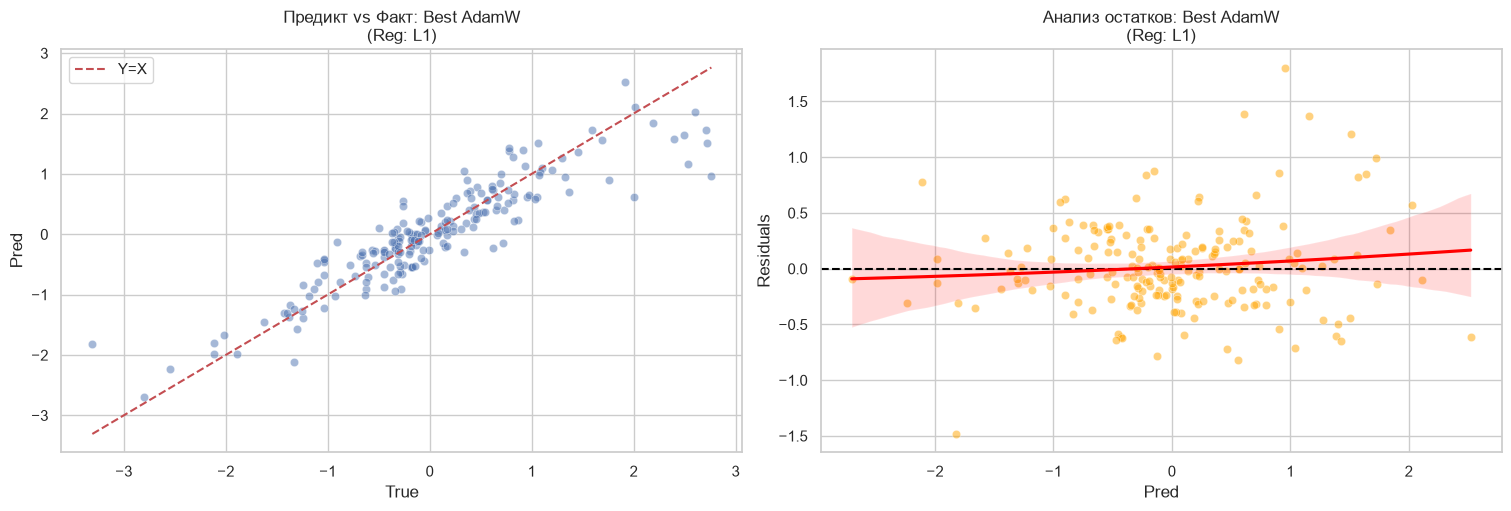

In [16]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~ГРАФИК 2 АНАЛИЗ ПРЕДСКАЗАНИЙ~~~~~~~~~~~~~~~~~~~~~~~~~~
y_test_true = y_test_scaled.flatten()

for key, data in final_comparison.items():
    if "predictions" not in data or "Mean Baseline" in key: continue
        
    preds = data["predictions"]
    res = y_test_true - preds
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    
    # Предикт vs Факт
    sns.scatterplot(x=y_test_true, y=preds, alpha=0.5, ax=ax1)
    ax1.plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--', label='Y=X')
    ax1.set(title=f"Предикт vs Факт: {key}", xlabel="True", ylabel="Pred")
    ax1.legend()
    
    # Остатки
    sns.scatterplot(x=preds, y=res, color='orange', alpha=0.5, ax=ax2)
    ax2.axhline(0, color='black', linestyle='--')
    sns.regplot(x=preds, y=res, scatter=False, order=2, color='red', ax=ax2)
    ax2.set(title=f"Анализ остатков: {key}", xlabel="Pred", ylabel="Residuals")
    
    plt.show()

Лучшая конфигурация: AdamW_L1_lr_0.05_lambda_0.0100 (Best Test MSE: 0.16678)


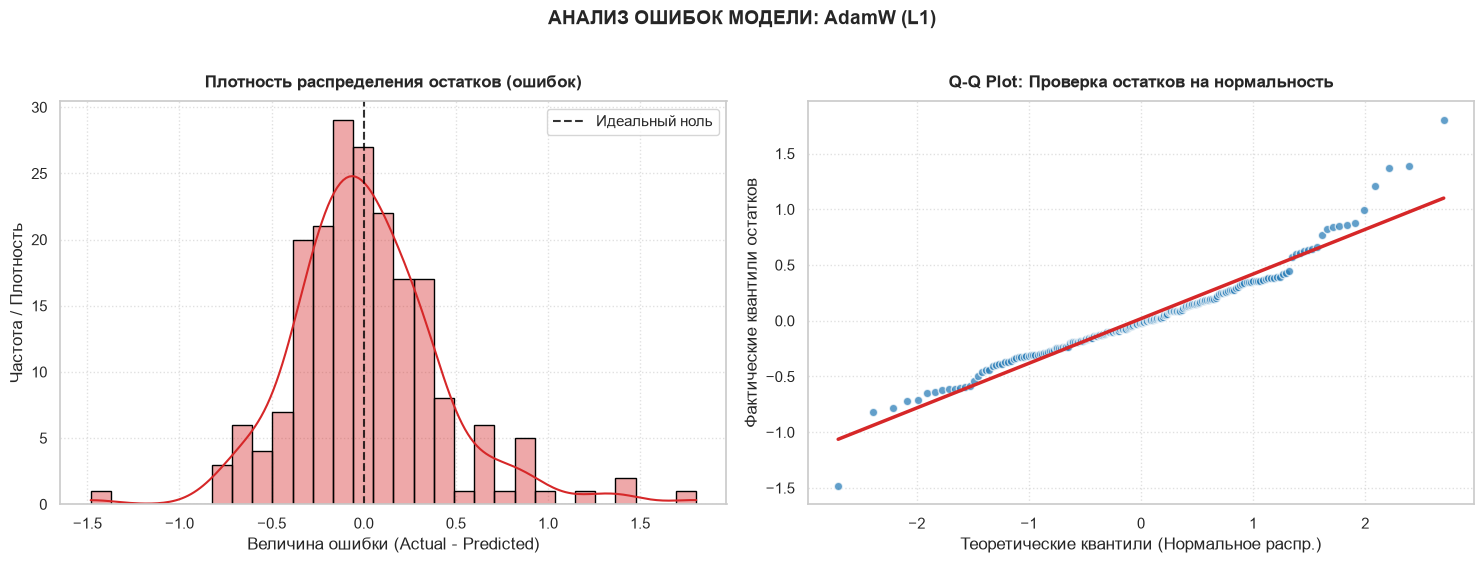

In [17]:
# Поиск лучшей модели
target_opt = absolute_best_opt
target_reg = absolute_best_reg
best_key = None
min_mse = float("inf")
for key, data in history_data.items():
    if data.get("opt") == target_opt and data.get("reg") == target_reg:
        if "best_mse" in data and data["best_mse"] < min_mse:
            min_mse = data["best_mse"]
            best_key = key

if best_key is None:
    raise ValueError(f"В history_data не найдено конфигураций для {target_opt} + {target_reg}")
print(f"Лучшая конфигурация: {best_key} (Best Test MSE: {min_mse:.5f})")

best_state = history_data[best_key]["best_state"]
final_model = nn.Linear(INPUT_DIM, 1)
final_model.load_state_dict(best_state)
final_model.eval()
with torch.no_grad():
    preds = final_model(X_test_tensor).numpy().flatten()
y_test_flat = y_test_scaled.flatten()
residuals = y_test_flat - preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

#~~~~~~~~~~~~~~~~~~~~~~~~~~ЛЕВЫЙ ГРАФИК Распределение остатков (Гистограмма + Плотность)~~~~~~~~~~~~~~~~~~~~~~~~~~
sns.histplot(residuals, kde=True, color='#d62728', alpha=0.4, ax=ax1, bins=30, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.8, linewidth=1.5, label='Идеальный ноль')
ax1.set_title("Плотность распределения остатков (ошибок)", fontweight='bold', fontsize=12, pad=10)
ax1.set_xlabel("Величина ошибки (Actual - Predicted)")
ax1.set_ylabel("Частота / Плотность")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

#~~~~~~~~~~~~~~~~~~~~~~~~~~ПРАВЫЙ ГРАФИК Q-Q Plot (Квантиль-Квантиль)~~~~~~~~~~~~~~~~~~~~~~~~~~
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('#1f77b4')
ax2.get_lines()[0].set_markeredgecolor('white')
ax2.get_lines()[0].set_alpha(0.7)
ax2.get_lines()[1].set_color('#d62728')
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title("Q-Q Plot: Проверка остатков на нормальность", fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel("Теоретические квантили (Нормальное распр.)")
ax2.set_ylabel("Фактические квантили остатков")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.suptitle(f"АНАЛИЗ ОШИБОК МОДЕЛИ: {target_opt} ({target_reg})", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Ручная реализация оптимизаторов 

## Adagrad

In [18]:
class AdaGradLinearRegression:
    def __init__(self, learning_rate=0.1, epsilon=1e-8):
        self.lr = learning_rate
        self.epsilon = epsilon
        
        # параметры модели (инициализируются при первом запуске)
        self.w = None
        self.b = 0.0
        
        # история градиентов для AdaGrad
        self.G_w = None
        self.G_b = 0.0
        
        # mean и std, чтобы потом правильно нормализовать новые тестовые данные
        self.mean = None
        self.std = None

    def _normalize(self, X):
        """метод для ручной Z-score нормализации"""
        if self.mean is None or self.std is None:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
            # Защита от деления на 0
            self.std[self.std == 0] = 1e-8
        return (X - self.mean) / self.std

    def _get_gradient(self, X_scaled, y):
        """метод для ручного расчета градиентов на матрицах"""
        N = X_scaled.shape[0]
        # Прогноз: X * w + b
        predictions = np.dot(X_scaled, self.w) + self.b
        err = predictions - y
        
        # Матричное вычисление градиентов
        grad_w = (2 / N) * np.dot(X_scaled.T, err)
        grad_b = (2 / N) * np.sum(err)
        return grad_w, grad_b

    def __call__(self, X, y, epochs=500, verbose=True):
        """
        Этот метод вызывается в момент ' model(X, y) ',
        запускает полный цикл обучения
        """
        X_scaled = self._normalize(X)
        num_features = X.shape[1]
        # инициализация веса и истории AdaGrad нулями
        if self.w is None:
            self.w = np.zeros(num_features)
            self.G_w = np.zeros(num_features)
            self.G_b = 0.0

        for epoch in range(1, epochs + 1):
            grad_w, grad_b = self._get_gradient(X_scaled, y)
            
            self.G_w += grad_w ** 2
            self.G_b += grad_b ** 2
            
            self.w -= (self.lr / (np.sqrt(self.G_w) + self.epsilon)) * grad_w
            self.b -= (self.lr / (np.sqrt(self.G_b) + self.epsilon)) * grad_b
            
            # Логирование ошибки каждые 50 эпох
            if verbose and (epoch == 1 or epoch % 50 == 0):
                current_preds = np.dot(X_scaled, self.w) + self.b
                mse = np.mean((current_preds - y) ** 2)
                print(f"Эпоха {epoch:3d} | Текущая ошибка (MSE): {mse:.4f}")
        return self.w, self.b

    def predict(self, X):
        if self.w is None:
            raise ValueError("Нет ничего, что можно было бы предсказать")
        X_scaled = (X - self.mean) / self.std
        return np.dot(X_scaled, self.w) + self.b

In [19]:
np.random.seed(69)
X_random = np.random.rand(200, 19) * 100  # например, площади от 0 до 100 кв.м.

true_w = np.random.uniform(-5, 5, size=19)
true_b = 15.0
noise = np.random.normal(0, 2, size=200)
y_random = np.dot(X_random, true_w) + true_b + noise

adagrad_model = AdaGradLinearRegression(learning_rate=0.4, epsilon=1e-8)

print("--- Старт обучения ---")
final_w, final_b = adagrad_model(X_random, y_random, epochs=400)
print("--- Обучение завершено ---\n")

print(f"Истинный b: {true_b}")
print(f"Найденный b: {final_b:.4f}")

--- Старт обучения ---
Эпоха   1 | Текущая ошибка (MSE): 145235.6000
Эпоха  50 | Текущая ошибка (MSE): 131952.0373
Эпоха 100 | Текущая ошибка (MSE): 125768.9845
Эпоха 150 | Текущая ошибка (MSE): 121186.7397
Эпоха 200 | Текущая ошибка (MSE): 117430.4267
Эпоха 250 | Текущая ошибка (MSE): 114199.9234
Эпоха 300 | Текущая ошибка (MSE): 111341.7380
Эпоха 350 | Текущая ошибка (MSE): 108764.9399
Эпоха 400 | Текущая ошибка (MSE): 106410.3951
--- Обучение завершено ---

Истинный b: 15.0
Найденный b: 15.0283


## AdamW

In [20]:
class AdamWLinearRegression:
    def __init__(self, learning_rate=0.05, beta1=0.9, beta2=0.999, epsilon=1e-8, weight_decay=0.01):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.weight_decay = weight_decay
        
        self.w = None
        self.b = 0.0
        # Первые моменты (m) и вторые моменты (v)
        self.m_w, self.v_w = None, None
        self.m_b, self.v_b = 0.0, 0.0
        # счетчик шагов (нужен для исправления смещения beta^t)
        self.t = 0
        # нормализация
        self.mean = None
        self.std = None

    def _normalize(self, X):
        if self.mean is None or self.std is None:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
            self.std[self.std == 0] = 1e-8
        return (X - self.mean) / self.std

    def _get_gradient(self, X_scaled, y):
        N = X_scaled.shape[0]
        predictions = np.dot(X_scaled, self.w) + self.b
        err = predictions - y
        # Чистые градиенты без L2-регуляризации (в AdamW она отделена!)
        grad_w = (2 / N) * np.dot(X_scaled.T, err)
        grad_b = (2 / N) * np.sum(err)
        return grad_w, grad_b

    def __call__(self, X, y, epochs=500, verbose=True):
        X_scaled = self._normalize(X)
        num_features = X.shape[1]
        # инициализация матриц при первом вызове
        if self.w is None:
            self.w = np.zeros(num_features)
            self.m_w = np.zeros(num_features)
            self.v_w = np.zeros(num_features)
            
        for epoch in range(1, epochs + 1):
            self.t += 1  # Увеличиваем шаг для формулы коррекции
            grad_w, grad_b = self._get_gradient(X_scaled, y)
            # шаг для весов (w) 
            self.m_w = self.beta1 * self.m_w + (1 - self.beta1) * grad_w
            self.v_w = self.beta2 * self.v_w + (1 - self.beta2) * (grad_w ** 2)
            
            # так называемый bias correction
            m_w_corrected = self.m_w / (1 - self.beta1 ** self.t)
            v_w_corrected = self.v_w / (1 - self.beta2 ** self.t)
            
            self.w -= self.lr * self.weight_decay * self.w + (self.lr / (np.sqrt(v_w_corrected) + self.epsilon)) * m_w_corrected
            
            # шаг AdamW для b (без weight decay)
            self.m_b = self.beta1 * self.m_b + (1 - self.beta1) * grad_b
            self.v_b = self.beta2 * self.v_b + (1 - self.beta2) * (grad_b ** 2)
            m_b_corrected = self.m_b / (1 - self.beta1 ** self.t)
            b_v_corrected = self.v_b / (1 - self.beta2 ** self.t)
            self.b -= (self.lr / (np.sqrt(b_v_corrected) + self.epsilon)) * m_b_corrected
            # Вывод логов
            if verbose and (epoch == 1 or epoch % 50 == 0):
                current_preds = np.dot(X_scaled, self.w) + self.b
                mse = np.mean((current_preds - y) ** 2)
                print(f"Эпоха {epoch:3d} | MSE: {mse:.4f}")
        return self.w, self.b

    def predict(self, X):
        if self.w is None:
            raise ValueError("Нет ничего, что можно было бы предсказать")
        X_scaled = self._normalize(X)
        return np.dot(X_scaled, self.w) + self.b

In [21]:
np.random.seed(69)
X_rand = np.random.randn(300, 19) * 50

true_weights = np.random.uniform(-3, 3, size=19)
true_bias = 42.0
y_rand = np.dot(X_rand, true_weights) + true_bias + np.random.normal(0, 5, size=300)

adamw_model = AdamWLinearRegression(learning_rate=1.5, weight_decay=0.001)
print("--- Старт обучения AdamW ---")
w_found, b_found = adamw_model(X_rand, y_rand, epochs=500)
print("--- Обучение завершено ---\n")

print(f"Оригинальный b: {true_bias}")
print(f"Найденный b:    {b_found:.4f}\n")

--- Старт обучения AdamW ---
Эпоха   1 | MSE: 148321.4499
Эпоха  50 | MSE: 32936.0631
Эпоха 100 | MSE: 6224.5090
Эпоха 150 | MSE: 1422.9204
Эпоха 200 | MSE: 567.2179
Эпоха 250 | MSE: 364.4971
Эпоха 300 | MSE: 285.2838
Эпоха 350 | MSE: 238.6461
Эпоха 400 | MSE: 205.7559
Эпоха 450 | MSE: 180.8558
Эпоха 500 | MSE: 161.2601
--- Обучение завершено ---

Оригинальный b: 42.0
Найденный b:    24.8757



## Сэмплированный датасет

In [22]:
df2 = pd.read_csv(dataset_path)
X_raw = df2.drop(columns=['Log_Цена']).values
y_raw = df2['Log_Цена'].values 

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=CONFIG["SEED"]
)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test_raw.reshape(-1, 1)).ravel()

---

In [23]:
modelAdamW = AdamWLinearRegression(learning_rate=1.5, weight_decay=0.001)

print("--- Обучение на Train ---")
modelAdamW(X_train_raw, y_train_scaled, epochs=1000)

y_test_pred_scaled = modelAdamW.predict(X_test_raw)
y_test_pred_log = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

test_mse = np.mean((y_test_pred_log - y_test_raw) ** 2)
print(f"\nФинальный MSE на тестовой выборке: {test_mse:.4f}")

--- Обучение на Train ---
Эпоха   1 | MSE: 69.6474
Эпоха  50 | MSE: 0.1851
Эпоха 100 | MSE: 0.1604
Эпоха 150 | MSE: 0.1589
Эпоха 200 | MSE: 0.1589
Эпоха 250 | MSE: 0.1589
Эпоха 300 | MSE: 0.1589
Эпоха 350 | MSE: 0.1589
Эпоха 400 | MSE: 0.1589
Эпоха 450 | MSE: 0.1589
Эпоха 500 | MSE: 0.1589
Эпоха 550 | MSE: 0.1589
Эпоха 600 | MSE: 0.1589
Эпоха 650 | MSE: 0.1589
Эпоха 700 | MSE: 0.1589
Эпоха 750 | MSE: 0.1589
Эпоха 800 | MSE: 0.1589
Эпоха 850 | MSE: 0.1589
Эпоха 900 | MSE: 0.1589
Эпоха 950 | MSE: 0.1589
Эпоха 1000 | MSE: 0.1589

Финальный MSE на тестовой выборке: 0.0461


In [24]:
modelAdaGrad = AdaGradLinearRegression(learning_rate=0.1, epsilon=1e-8)

print("--- Старт обучения AdaGrad на Train ---")
modelAdaGrad(X_train_raw, y_train_scaled, epochs=1000, verbose=True)

y_test_pred_scaled = modelAdaGrad.predict(X_test_raw)
y_test_pred_log = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

test_mse = np.mean((y_test_pred_log - y_test_raw) ** 2)
print(f"\nФинальный MSE (AdaGrad) на тестовой выборке: {test_mse:.4f}")

--- Старт обучения AdaGrad на Train ---
Эпоха   1 | Текущая ошибка (MSE): 0.6466
Эпоха  50 | Текущая ошибка (MSE): 0.1610
Эпоха 100 | Текущая ошибка (MSE): 0.1590
Эпоха 150 | Текущая ошибка (MSE): 0.1589
Эпоха 200 | Текущая ошибка (MSE): 0.1589
Эпоха 250 | Текущая ошибка (MSE): 0.1589
Эпоха 300 | Текущая ошибка (MSE): 0.1589
Эпоха 350 | Текущая ошибка (MSE): 0.1589
Эпоха 400 | Текущая ошибка (MSE): 0.1589
Эпоха 450 | Текущая ошибка (MSE): 0.1589
Эпоха 500 | Текущая ошибка (MSE): 0.1589
Эпоха 550 | Текущая ошибка (MSE): 0.1589
Эпоха 600 | Текущая ошибка (MSE): 0.1589
Эпоха 650 | Текущая ошибка (MSE): 0.1589
Эпоха 700 | Текущая ошибка (MSE): 0.1589
Эпоха 750 | Текущая ошибка (MSE): 0.1589
Эпоха 800 | Текущая ошибка (MSE): 0.1589
Эпоха 850 | Текущая ошибка (MSE): 0.1589
Эпоха 900 | Текущая ошибка (MSE): 0.1589
Эпоха 950 | Текущая ошибка (MSE): 0.1589
Эпоха 1000 | Текущая ошибка (MSE): 0.1589

Финальный MSE (AdaGrad) на тестовой выборке: 0.0461
